In [ ]:
import dr_datacube
import numpy as np
import polars as pl

from matplotlib import pyplot as plt
import polars_vec_ops as vec


In [105]:
# df_combined = pl.read_parquet("/Users/corbettb/Documents/GitHub/dynamic_routing_facemap/results/decoding_results.parquet")
# df_visual = pl.read_parquet("/Users/corbettb/Documents/GitHub/dynamic_routing_facemap/results/decoding_results_visual.parquet")
# df_auditory = pl.read_parquet("/Users/corbettb/Documents/GitHub/dynamic_routing_facemap/results/decoding_results_auditory.parquet")
# df_lbo = pl.read_parquet("/Users/corbettb/Documents/GitHub/dynamic_routing_facemap/results/decoding_results_leave_block_out.parquet")
# df_lbo_vis = pl.read_parquet("/Users/corbettb/Documents/GitHub/dynamic_routing_facemap/results/decoding_results_leave_block_out_visual.parquet")
# df_lbo_aud = pl.read_parquet("/Users/corbettb/Documents/GitHub/dynamic_routing_facemap/results/decoding_results_leave_block_out_auditory.parquet")
# df_lbo_aud_target = pl.read_parquet("/Users/corbettb/Documents/GitHub/dynamic_routing_facemap/results/decoding_results_leave_block_out_auditory_target.parquet")
df_combined = pl.read_parquet("/Users/corbettb/Documents/GitHub/dynamic_routing_facemap/results/decoding_results_leave_block_out_balanced_accuracy_balancedblocks_onlytargets.parquet")
df_vis_targets = pl.read_parquet("/Users/corbettb/Documents/GitHub/dynamic_routing_facemap/results/decoding_results_leave_block_out_balanced_accuracy_balancedblocks_onlyvistargets.parquet")
df_aud_targets = pl.read_parquet("/Users/corbettb/Documents/GitHub/dynamic_routing_facemap/results/decoding_results_leave_block_out_balanced_accuracy_balancedblocks_onlyaudtargets.parquet")

Text(0, 0.5, 'CV Score: lick vs no lick trials')

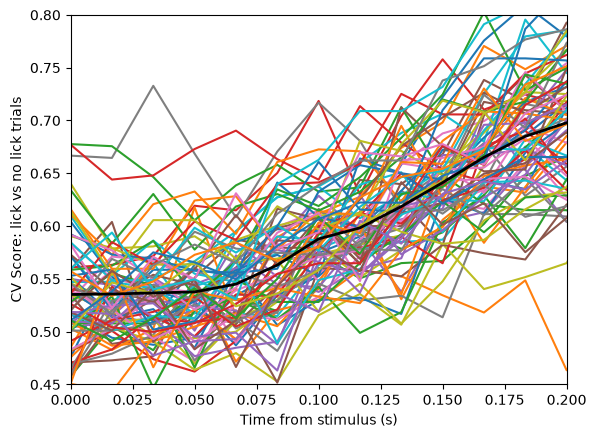

In [26]:
window_centers  = np.array(df_combined['window_center_s'][0]) + 1/120 #add in a half frame to account for motSVD diff

scores = np.stack(df_combined['cv_scores'].to_numpy())

plt.plot(window_centers, scores.T)
plt.plot(window_centers, scores.mean(axis=0), color='k', linewidth=2)

plt.xlim(0, 0.2)
plt.ylim(0.45, 0.8)
plt.xlabel('Time from stimulus (s)')
plt.ylabel('CV Score: lick vs no lick trials')

Text(0, 0.5, 'CV Score: lick vs no lick trials')

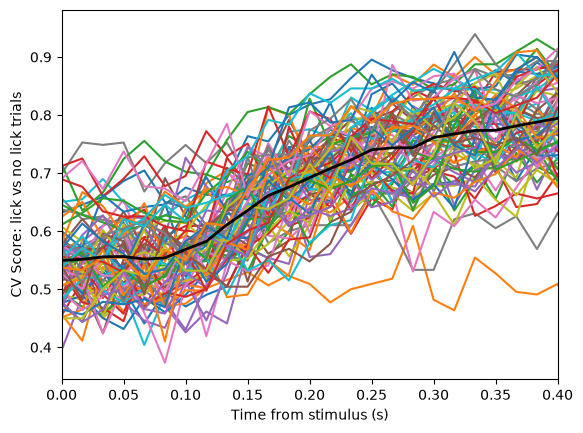

In [27]:
window_centers  = np.array(df_visual['window_center_s'][0]) + 1/120 #add in a half frame to account for motSVD diff

scores = np.stack(df_visual['cv_scores'].to_numpy())

plt.plot(window_centers, scores.T)
plt.plot(window_centers, scores.mean(axis=0), color='k', linewidth=2)

plt.xlim(0, 0.4)
# plt.ylim(0.45, 0.8)
plt.xlabel('Time from stimulus (s)')
plt.ylabel('CV Score: lick vs no lick trials')

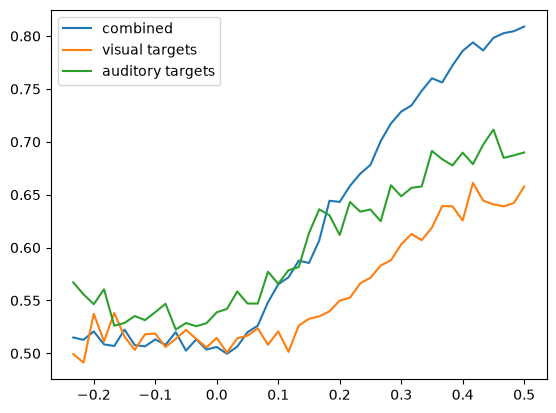

In [107]:
# for df in [df_combined, df_visual, df_auditory, df_lbo, df_lbo_vis, 
#            df_lbo_aud, df_lbo_aud_target, df_lbo_balanced_accuracy]:

for df in [df_combined, df_vis_targets, df_aud_targets]:
    window_centers  = np.array(df['window_center_s'][0]) + 1/120 #add in a half frame to account for motSVD diff
    scores = np.stack((
            df
            .with_columns(pl.col('session_id').str.split('_').list.get(0).alias('mouse_id'))
            .group_by('mouse_id')
            .agg(vec.mean("cv_scores").alias("mouse_mean_cv_scores"))
            # .select('mouse_mean_cv_scores')
        )['mouse_mean_cv_scores'].drop_nulls().to_numpy())

    #baseline subtract the mean of the first 5 time points
    # scores = scores - scores[:, :5].mean(axis=1)[:, None]

    # plt.plot(window_centers, scores.T)
    plt.plot(window_centers, scores.mean(axis=0))

plt.legend(['combined', 'visual targets', 'auditory targets'])


In [66]:
scores.shape

(81, 45)

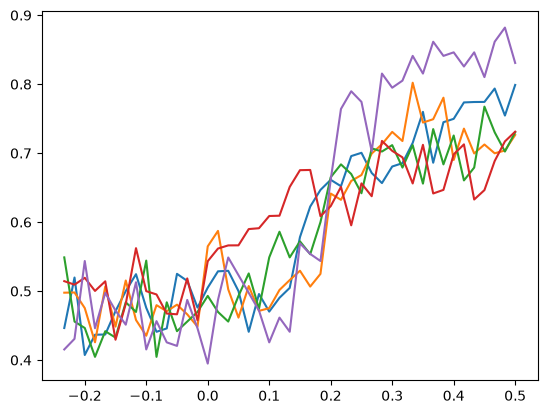

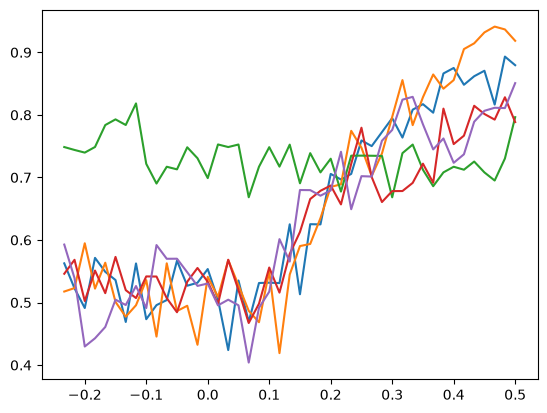

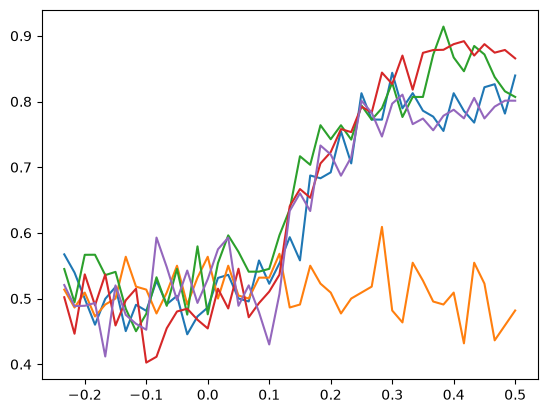

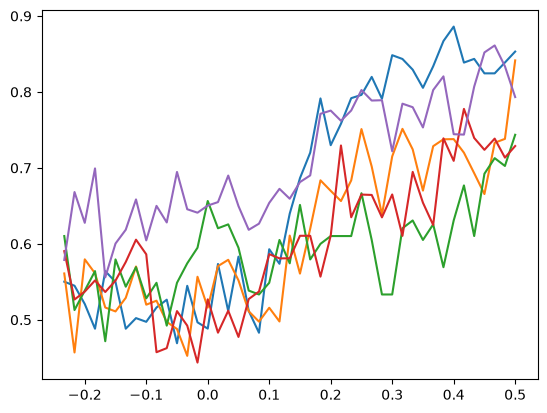

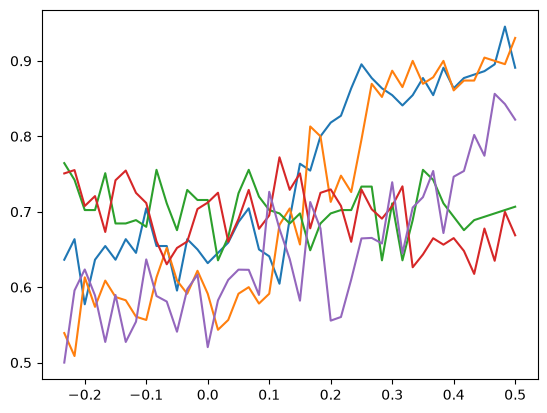

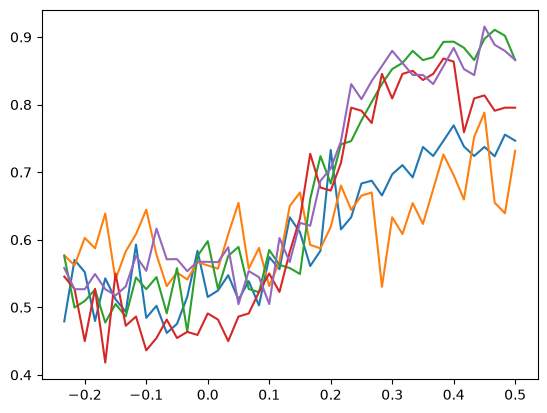

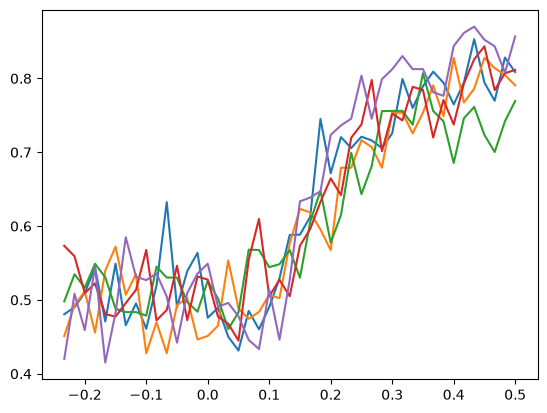

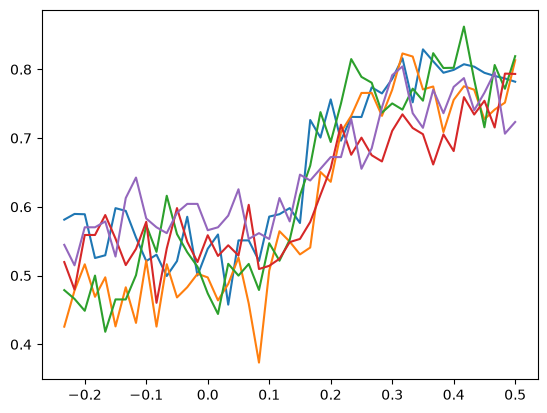

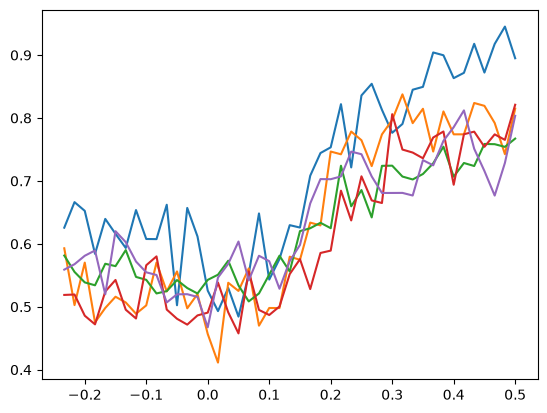

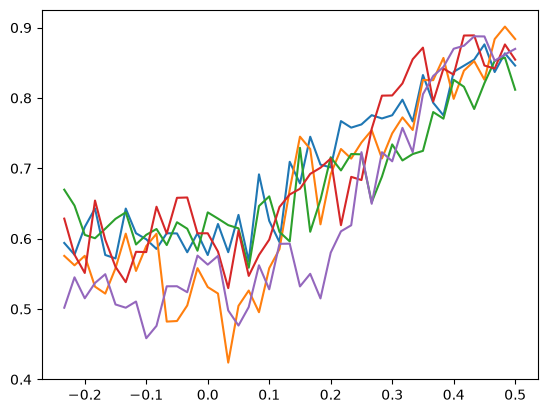

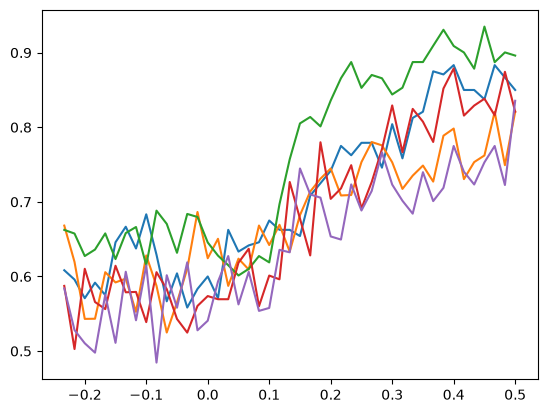

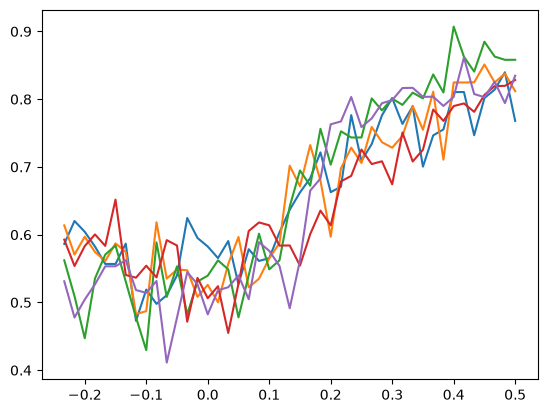

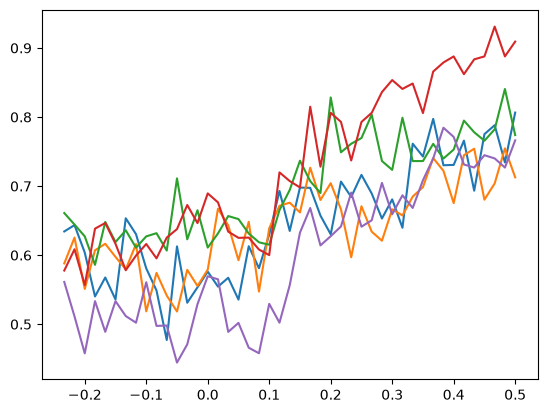

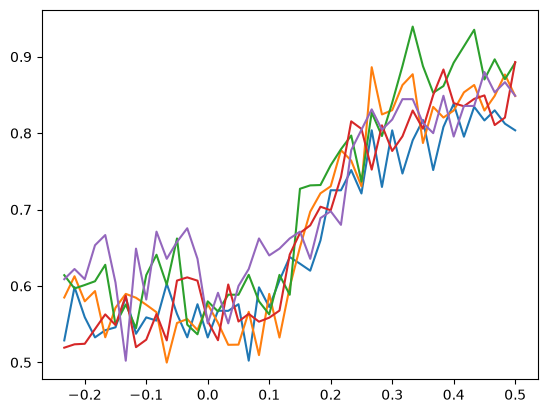

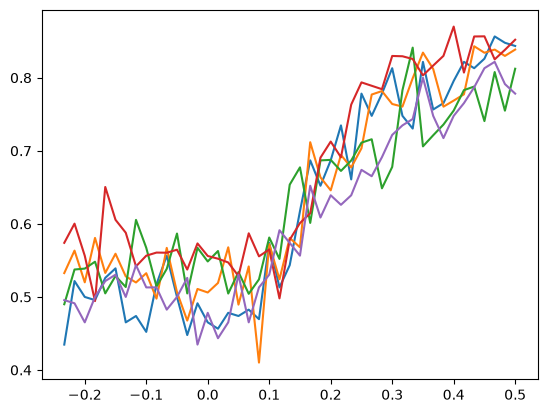

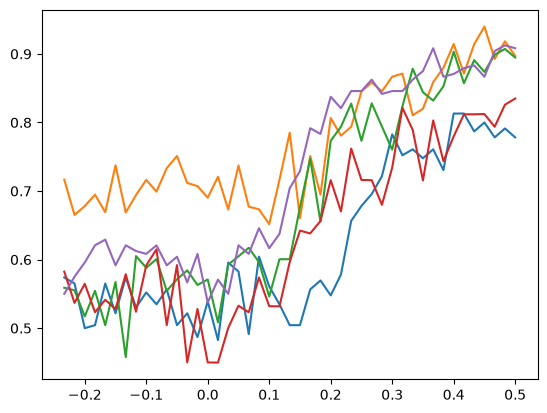

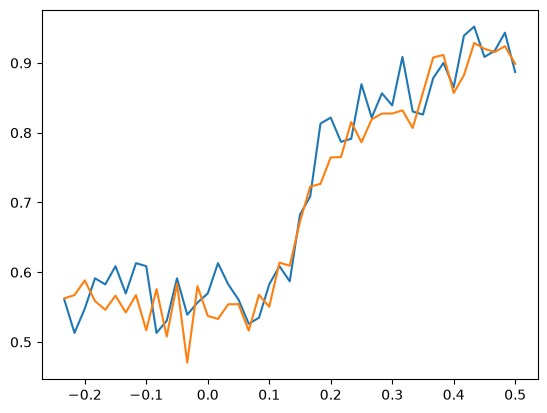

In [68]:
# Plot individual cross-validation scores for the current dataframe
# plot five per plot then make a new plot
df = df_visual
window_centers = np.array(df['window_center_s'][0]) + 1/120
scores = np.stack(df['cv_scores'].drop_nulls().to_numpy())
for i in range(0, scores.shape[0], 5):
    plt.figure()
    for j in range(i, min(i+5, scores.shape[0])):
        plt.plot(window_centers, scores[j])
    plt.show()

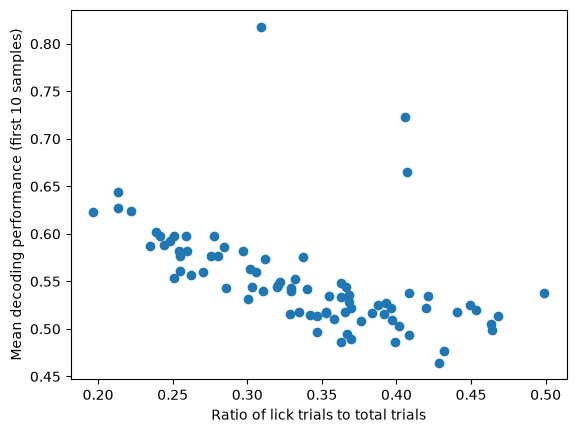

In [24]:
# plot the ratio of lick trials to total trials against the decoding performance in first 10 samples
ratio = df["n_lick_trials"] / df["n_trials"]
performance_first_10 = df.with_columns(
    pl.col("cv_scores").list.slice(0, 10).alias("performance_first_10")
).select("performance_first_10")

mean_performance_first_10 = performance_first_10.select(
    pl.col("performance_first_10").list.mean()
).to_series()

plt.scatter(ratio, mean_performance_first_10)
plt.xlabel("Ratio of lick trials to total trials")
plt.ylabel("Mean decoding performance (first 10 samples)")
plt.show()